In [2]:
from sklift.datasets import fetch_x5
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklift.metrics import uplift_at_k
from sklift.models import SoloModel

pd.set_option('display.float_format', lambda x: '%.3f' % x)

dataset = fetch_x5()

/Users/eugenechua/.pyenv/versions/boston_uni/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This dataset is like a dictionary like object. Lets take a closer look what it is.

In [3]:
dataset.keys()

dict_keys(['data', 'target', 'treatment', 'DESCR', 'feature_names', 'target_name', 'treatment_name'])

In [4]:
### data has 3 datasets
datasets_data = dataset['data']

### clients data
clients = datasets_data['clients']

### train data
train = datasets_data['train']

### purchases
purchases = datasets_data['purchases']

### Let's look at other dataset objects

### treatment feature: 
## 1 - mean there was an interaction with customer; 0 - no interaction

treatment = dataset['treatment']

### target feature

target = dataset['target']

In [5]:
print(clients.shape)
clients.head(5)

(400162, 5)


,client_id,first_issue_date,first_redeem_date,age,gender
0,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U
1,000036f903,2017-04-10 13:54:23,2017-04-23 12:37:56,72,F
2,000048b7a6,2018-12-15 13:33:11,NaN,68,F
3,000073194a,2017-05-23 12:56:14,2017-11-24 11:18:01,60,F
4,00007c7133,2017-05-22 16:17:08,2018-12-31 17:17:33,67,U


let us study the datasets more in detail alright?

In [6]:
print(clients.isnull().sum())

client_id                0
first_issue_date         0
first_redeem_date    35469
age                      0
gender                   0
dtype: int64


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("white")

for c in ["first_issue_date", "first_redeem_date"]:
    clients[c] = pd.to_datetime(clients[c])

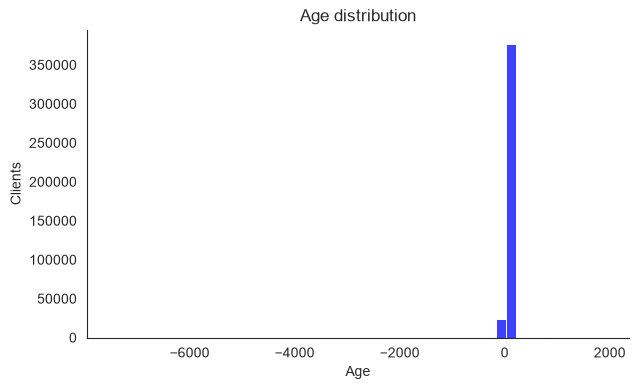

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(clients["age"], bins=50, color="blue", edgecolor="white", ax=ax)
ax.set_title("Age distribution")
ax.set_xlabel("Age"); ax.set_ylabel("Clients")
sns.despine()
plt.show()


In [9]:
print(clients['age'].max())
print(clients['age'].median())
print(clients['age'].min())

1901
45.0
-7491


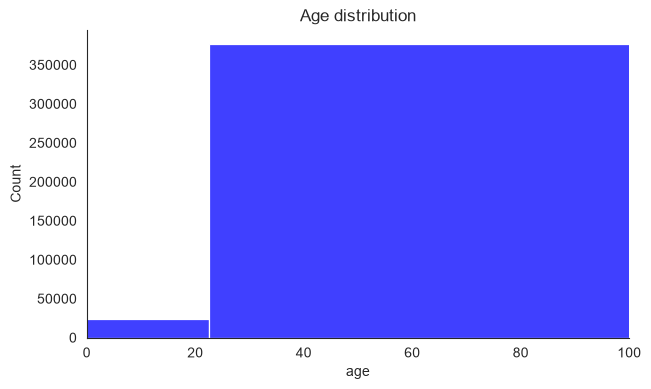

<Axes: xlabel='age', ylabel='Count'>

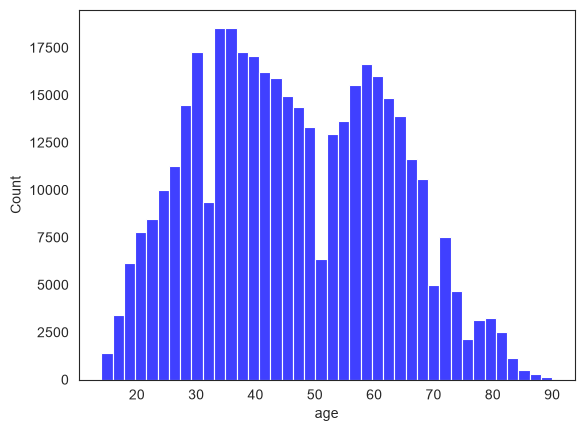

In [10]:
# just zoom the plot (keeps data intact)
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(clients["age"], bins=40, color="blue", edgecolor="white", ax=ax)
ax.set_xlim(0, 100)
ax.set_title("Age distribution")
sns.despine()
plt.show()

# or filter to a plausible range before plotting
plausible_age = clients["age"].between(14, 90)
sns.histplot(clients.loc[plausible_age, "age"], bins=40, color="blue", edgecolor="white")


In [11]:
clients["age"].describe()

count   400162.000
mean        46.488
std         43.871
min      -7491.000
25%         34.000
50%         45.000
75%         59.000
max       1901.000
Name: age, dtype: float64

In [12]:
implausible = ~clients["age"].between(0, 100)
implausible.sum(), implausible.mean()   # count and % of rows


(np.int64(1145), np.float64(0.0028613411568314834))

In [13]:
# cleaning it up!
clients = clients[clients["age"].between(0, 100)].copy()
print(clients.shape)


(399017, 5)


/var/folders/hq/mcpk2xjd3zv1rdk128m1qvgm0000gn/T/ipykernel_91628/3934104074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="gender", data=clients, order=order,


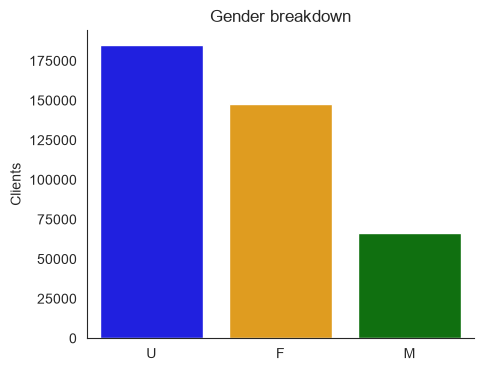

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
order = clients["gender"].value_counts().index
sns.countplot(x="gender", data=clients, order=order,
              palette=['blue', 'orange', 'green'][:len(order)], ax=ax)
ax.set_title("Gender breakdown")
ax.set_xlabel(""); ax.set_ylabel("Clients")
sns.despine()
plt.show()


So many unidentified gender!

/var/folders/hq/mcpk2xjd3zv1rdk128m1qvgm0000gn/T/ipykernel_91628/1372547082.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="gender", y="age", data=clients,


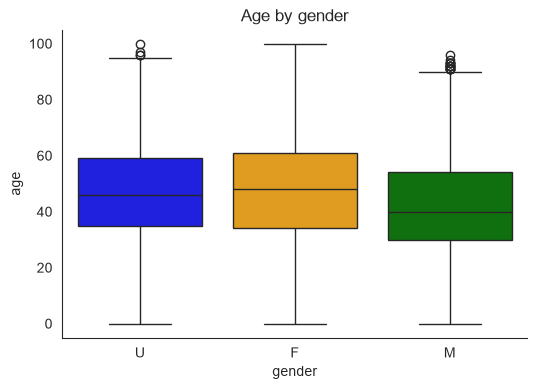

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="gender", y="age", data=clients,
            palette=['blue', 'orange', 'green'], ax=ax)
ax.set_title("Age by gender")
sns.despine()
plt.show()


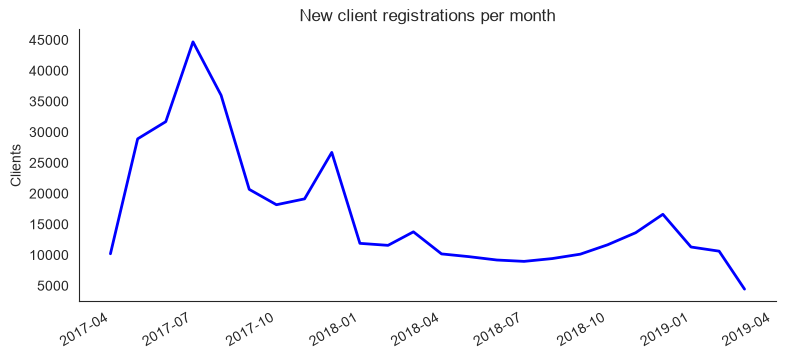

In [16]:
monthly = clients.set_index("first_issue_date").resample("MS").size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly.values, color="blue", lw=2)
ax.set_title("New client registrations per month")
ax.set_ylabel("Clients")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
sns.despine()
plt.show()


In [17]:
redeemed = clients["first_redeem_date"].notna()
redeemed.value_counts()

first_redeem_date
True     363743
False     35274
Name: count, dtype: int64

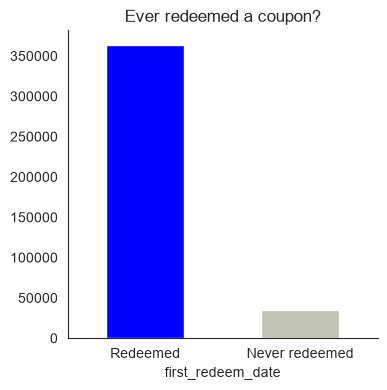

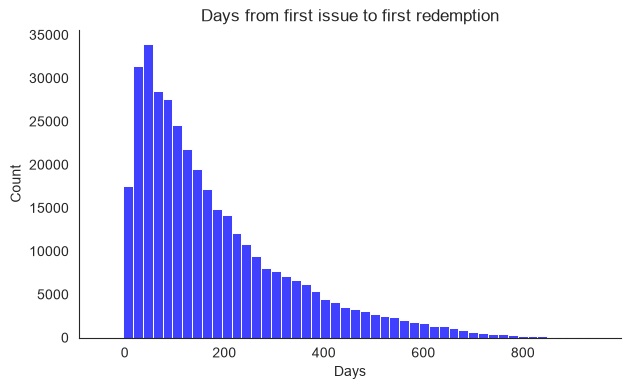

In [18]:
# a) share who never redeemed a coupon
redeemed = clients["first_redeem_date"].notna()
fig, ax = plt.subplots(figsize=(4, 4))
redeemed.value_counts().rename({True: "Redeemed", False: "Never redeemed"}).plot(
    kind="bar", color=["blue", "#c3c2b7"], ax=ax
)
ax.set_title("Ever redeemed a coupon?")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
sns.despine()
plt.show()

# b) days between issue and first redemption, for those who did
days_to_redeem = (clients.loc[redeemed, "first_redeem_date"]
                   - clients.loc[redeemed, "first_issue_date"]).dt.days

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(days_to_redeem, bins=50, color="blue", edgecolor="white", ax=ax)
ax.set_title("Days from first issue to first redemption")
ax.set_xlabel("Days")
sns.despine()
plt.show()


In [19]:
clients['gender'].value_counts()

gender
U    185021
F    147616
M     66380
Name: count, dtype: int64

In [20]:
clients.groupby("gender")["first_redeem_date"].apply(lambda x: x.notna().mean())


gender
F   0.929
M   0.896
U   0.903
Name: first_redeem_date, dtype: float64

In [21]:
print(train.shape)
train.head(5)

(200039, 1)


,client_id
0,000012768d
1,000036f903
2,00010925a5
3,0001f552b0
4,00020e7b18


In [22]:
train['treatment'] = treatment
train['target'] = target
train.head(5)

,client_id,treatment,target
0,000012768d,0,1
1,000036f903,1,1
2,00010925a5,1,1
3,0001f552b0,1,1
4,00020e7b18,1,1


In [23]:
# Next I will try combining the train dataset with the client's demographics

train_df = pd.merge(train, clients, how='left', on='client_id')
print(train_df.shape)
train_df.head(5)

(200039, 7)


,client_id,treatment,target,first_issue_date,first_redeem_date,age,gender
0,000012768d,0,1,2017-08-05 15:40:48,2018-01-04 19:30:07,45.000,U
1,000036f903,1,1,2017-04-10 13:54:23,2017-04-23 12:37:56,72.000,F
2,00010925a5,1,1,2018-07-24 16:21:29,2018-09-14 16:12:49,83.000,U
3,0001f552b0,1,1,2017-06-30 19:20:38,2018-08-28 12:59:45,33.000,F
4,00020e7b18,1,1,2017-11-27 11:41:45,2018-01-10 17:50:05,73.000,U


In [35]:
train_df.isnull().sum()

client_id                0
treatment                0
target                   0
first_issue_date       577
first_redeem_date    18030
age                    577
gender                 577
dtype: int64

This 577 missing fields is probably the case of customers in training datasets not found in the client dataset (remember I only included customers whose age between 0 to 100)

In [24]:
pd.crosstab(train_df['treatment'],train_df['target'])/train_df.shape[0]

target,0,1
treatment,,
0,0.198,0.302
1,0.182,0.318


We can see for a GIVEN target class, the treatment and control group size is almost equal...

In [25]:
# Looking at purchases.
print(purchases.shape)
purchases.head(5)

(45786568, 13)


,client_id,transaction_id,transaction_datetime,regular_points_received,express_points_received,regular_points_spent,express_points_spent,purchase_sum,store_id,product_id,product_quantity,trn_sum_from_iss,trn_sum_from_red
0,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.000,0.000,0.000,0.000,1007.000,54a4a11a29,9a80204f78,2.000,80.000,NaN
1,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.000,0.000,0.000,0.000,1007.000,54a4a11a29,da89ebd374,1.000,65.000,NaN
2,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.000,0.000,0.000,0.000,1007.000,54a4a11a29,0a95e1151d,1.000,24.000,NaN
3,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.000,0.000,0.000,0.000,1007.000,54a4a11a29,4055b15e4a,2.000,50.000,NaN
4,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.000,0.000,0.000,0.000,1007.000,54a4a11a29,a685f1916b,1.000,22.000,NaN


In [26]:
print(purchases.isnull().sum())

client_id                         0
transaction_id                    0
transaction_datetime              0
regular_points_received           0
express_points_received           0
regular_points_spent              0
express_points_spent              0
purchase_sum                      0
store_id                          0
product_id                        0
product_quantity                  0
trn_sum_from_iss                  0
trn_sum_from_red           42743212
dtype: int64


In [27]:
purchases["trn_sum_from_red"].isna().sum()

# does null trn_sum_from_red line up with zero points spent?
(purchases["trn_sum_from_red"].isna() ==
 ((purchases["regular_points_spent"] == 0) & (purchases["express_points_spent"] == 0))).mean()


np.float64(0.999838817357964)

`trn_sum_from_red` is `NaN` not because data is missing/broken, but because most individual purchase line-items don't involve any redemption at all. It is technically not applicable for that row - same pattern as `first_redeem_date` being null for clients who had never redeemed.

In [28]:
# First thing first, I will try filtering the purchases dataset to only include customers in the train set
purchases_train = purchases[purchases["client_id"].isin(train["client_id"])]
print(purchases_train.shape)
purchases_train.head(5)


(22882690, 13)


,client_id,transaction_id,transaction_datetime,regular_points_received,express_points_received,regular_points_spent,express_points_spent,purchase_sum,store_id,product_id,product_quantity,trn_sum_from_iss,trn_sum_from_red
0,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.000,0.000,0.000,0.000,1007.000,54a4a11a29,9a80204f78,2.000,80.000,NaN
1,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.000,0.000,0.000,0.000,1007.000,54a4a11a29,da89ebd374,1.000,65.000,NaN
2,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.000,0.000,0.000,0.000,1007.000,54a4a11a29,0a95e1151d,1.000,24.000,NaN
3,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.000,0.000,0.000,0.000,1007.000,54a4a11a29,4055b15e4a,2.000,50.000,NaN
4,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.000,0.000,0.000,0.000,1007.000,54a4a11a29,a685f1916b,1.000,22.000,NaN


In [29]:
client_features = purchases_train.groupby("client_id").agg(
    n_transactions=("transaction_id", "nunique"),
    n_products=("product_id", "nunique"),
    total_purchase_sum=("purchase_sum", "sum"),
    total_quantity=("product_quantity", "sum"),
    avg_purchase_sum=("purchase_sum", "mean"),
).reset_index()

print(client_features.shape)
client_features.head()


(200039, 6)


,client_id,n_transactions,n_products,total_purchase_sum,total_quantity,avg_purchase_sum
0,000012768d,4,46,40809.000,54.000,784.788
1,000036f903,32,96,58765.000,169.000,362.747
2,00010925a5,18,58,28494.000,79.000,365.308
3,0001f552b0,15,79,47974.340,106.000,557.841
4,00020e7b18,18,175,558970.460,394.000,2055.038


In [30]:
train_df.head(5)

,client_id,treatment,target,first_issue_date,first_redeem_date,age,gender
0,000012768d,0,1,2017-08-05 15:40:48,2018-01-04 19:30:07,45.000,U
1,000036f903,1,1,2017-04-10 13:54:23,2017-04-23 12:37:56,72.000,F
2,00010925a5,1,1,2018-07-24 16:21:29,2018-09-14 16:12:49,83.000,U
3,0001f552b0,1,1,2017-06-30 19:20:38,2018-08-28 12:59:45,33.000,F
4,00020e7b18,1,1,2017-11-27 11:41:45,2018-01-10 17:50:05,73.000,U


In [31]:
print(train_df['client_id'].nunique())
print(client_features['client_id'].nunique())

200039
200039


In [33]:
# Then this would be the complete dataset - stitching the client's demograph info together with its transaction information!
final_merged_train_df = pd.merge(train_df, client_features, how='inner', on='client_id')
print(final_merged_train_df.shape)
final_merged_train_df.head(5)

(200039, 12)


,client_id,treatment,target,first_issue_date,first_redeem_date,age,gender,n_transactions,n_products,total_purchase_sum,total_quantity,avg_purchase_sum
0,000012768d,0,1,2017-08-05 15:40:48,2018-01-04 19:30:07,45.000,U,4,46,40809.000,54.000,784.788
1,000036f903,1,1,2017-04-10 13:54:23,2017-04-23 12:37:56,72.000,F,32,96,58765.000,169.000,362.747
2,00010925a5,1,1,2018-07-24 16:21:29,2018-09-14 16:12:49,83.000,U,18,58,28494.000,79.000,365.308
3,0001f552b0,1,1,2017-06-30 19:20:38,2018-08-28 12:59:45,33.000,F,15,79,47974.340,106.000,557.841
4,00020e7b18,1,1,2017-11-27 11:41:45,2018-01-10 17:50:05,73.000,U,18,175,558970.460,394.000,2055.038


In [34]:
final_merged_train_df.isnull().sum()

client_id                 0
treatment                 0
target                    0
first_issue_date        577
first_redeem_date     18030
age                     577
gender                  577
n_transactions            0
n_products                0
total_purchase_sum        0
total_quantity            0
avg_purchase_sum          0
dtype: int64